# import libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, balanced_accuracy_score, roc_auc_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve
from imblearn.over_sampling import SMOTE
import pandas as pd

# create dataset

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    weights=[0.1, 0.9],
    random_state=42
)

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, stratify=y,random_state=42)

# train randomforest classifier

In [3]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=5,          # Maximum depth of trees
    random_state=42,
    n_jobs=-1              # Use all processors
)

In [4]:
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
y_proba = rf_classifier.predict_proba(X_test)[:, 0]

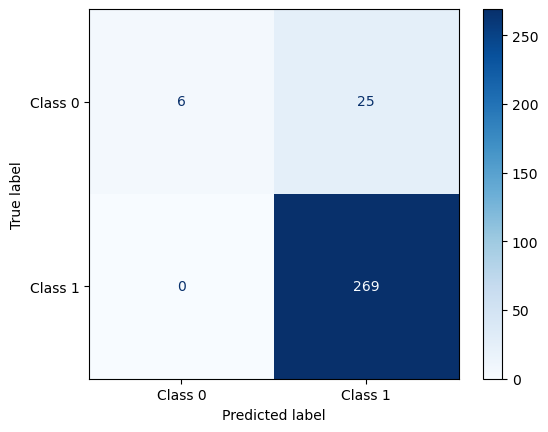

In [5]:
class_names = ["Class 0", "Class 1"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d")
plt.show()

In [6]:
recall = recall_score(y_test, y_pred, pos_label=0)
print("Recall (class 0):", recall)

Recall (class 0): 0.1935483870967742


In [7]:
acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", acc)

Balanced Accuracy: 0.5967741935483871


In [8]:
auc = roc_auc_score((y_test == 0).astype(int), y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.9237318623336132


# Apply smote

In [9]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE:", dict(zip(*np.unique(y_train_sm, return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(71), np.int64(1): np.int64(629)}
After SMOTE: {np.int64(0): np.int64(629), np.int64(1): np.int64(629)}


C:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass

In [10]:
rf_classifier_smote = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=5,          # Maximum depth of trees
    random_state=42,
    n_jobs=-1              # Use all processors
)

rf_classifier_smote.fit(X_train_sm, y_train_sm)

RandomForestClassifier(max_depth=5, n_jobs=-1, random_state=42)

In [11]:
sm_y_pred = rf_classifier_smote.predict(X_test)
sm_y_proba = rf_classifier_smote.predict_proba(X_test)[:, 0]

sm_bal_acc = balanced_accuracy_score(y_test, sm_y_pred)
sm_auc = roc_auc_score((y_test == 0).astype(int), sm_y_proba)
sm_recall = recall_score(y_test, sm_y_pred, pos_label=0)

print("Recall (class 0):", sm_recall)
print("Balanced Accuracy:", sm_bal_acc)
print("ROC-AUC:", sm_auc)

Recall (class 0): 0.7096774193548387
Balanced Accuracy: 0.8381100851421034
ROC-AUC: 0.9342846864132389


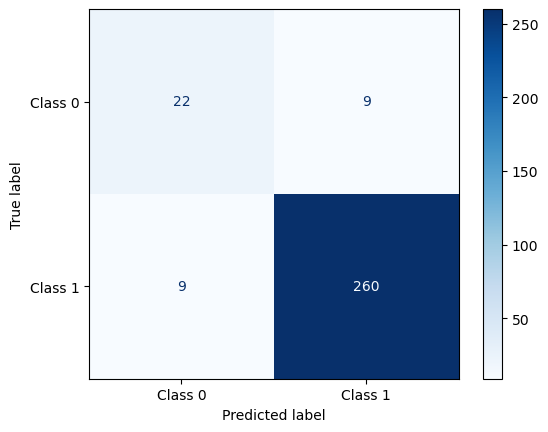

In [12]:
class_names = ["Class 0", "Class 1"]
cm = confusion_matrix(y_test, sm_y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d")
plt.show()

# Play with thresholds

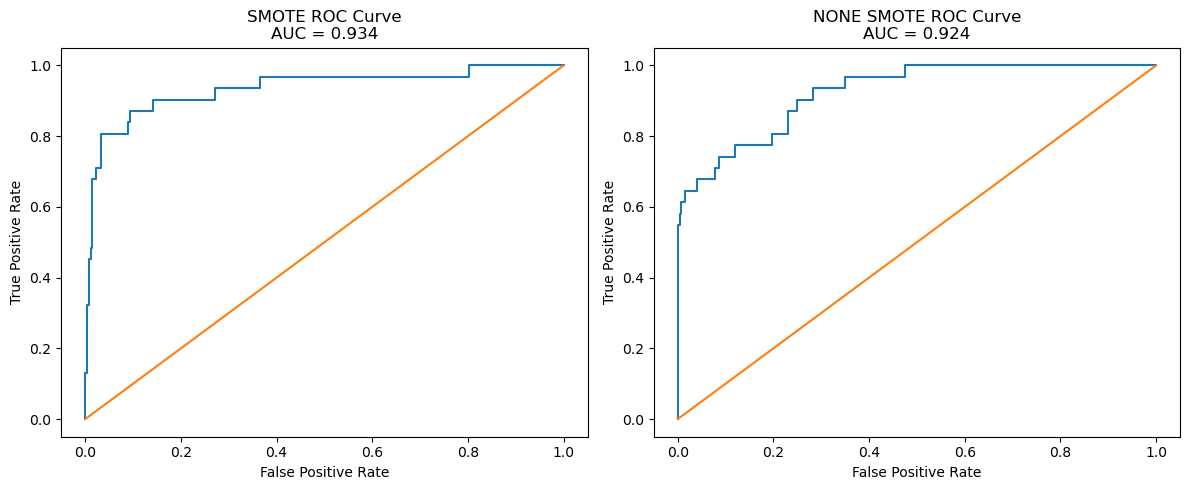

In [14]:
# --- First model ---
fpr1, tpr1, thresholds1 = roc_curve(y_test, sm_y_proba, pos_label=0)
auc1 = roc_auc_score((y_test == 0).astype(int), sm_y_proba)

# --- Second model ---
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_proba, pos_label=0)
auc2 = roc_auc_score((y_test == 0).astype(int), y_proba)

# --- Create subplots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot
axes[0].plot(fpr1, tpr1)
axes[0].plot([0, 1], [0, 1])  # random baseline
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"SMOTE ROC Curve\nAUC = {auc1:.3f}")

# Right plot
axes[1].plot(fpr2, tpr2)
axes[1].plot([0, 1], [0, 1])  # random baseline
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"NONE SMOTE ROC Curve\nAUC = {auc2:.3f}")

plt.tight_layout()
plt.show()


In [17]:
thresholds = np.linspace(0, 1, 100)
recalls = []
precisions = []

for threshold in thresholds:
    new_y_pred = np.where(sm_y_proba >= threshold, 0, 1)
    recalls.append(recall_score(y_test, new_y_pred, pos_label=0))
    precisions.append(precision_score(y_test, new_y_pred, pos_label=0))

C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precisio

In [24]:
df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions,
    "recall": recalls
})

df.head().T

,0,1,2,3,4
threshold,0.000000,0.010101,0.020202,0.030303,0.040404
precision,0.103333,0.103333,0.103333,0.103333,0.105085
recall,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
df.tail().T

,95,96,97,98,99
threshold,0.959596,0.969697,0.979798,0.989899,1.0
precision,0.000000,0.000000,0.000000,0.000000,0.0
recall,0.000000,0.000000,0.000000,0.000000,0.0


In [28]:
threshold_idx = 10
threshold = thresholds[threshold_idx]
df[df.threshold == threshold]

,threshold,precision,recall
10,0.10101,0.136364,0.967742


این دو معیار مانند کفه های یک ترازو هستند. افزایش یکی منجر به کاهش دیگری میشود. بسته به هدفی که داریم بایستی مقدار آستانه مورد نظر را پیدا کنیم. 
در تشخیص بیماری ممکن است اهمیت بیشتری برای کشف بیماری داشته باشیم و این بین یک فرد سالم را نیز بیمار تشخیص دهیم که اشکالی نداشته باشد.
در سیستم دزدگیر چنانچه بیش از اندازه سیستم خطای کشف دزد بدهد آزار دهنده خواهد بود.

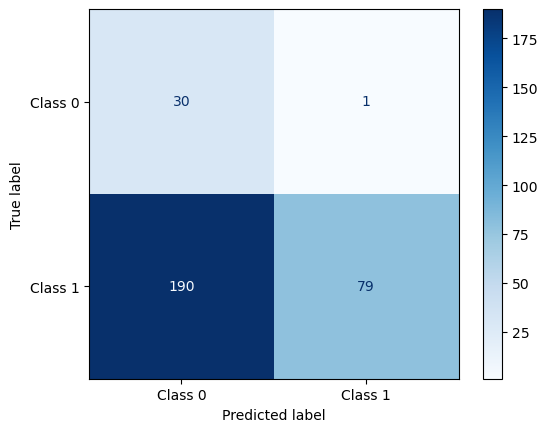

In [29]:
new_y_pred = np.where(sm_y_proba >= threshold, 0, 1)
class_names = ["Class 0", "Class 1"]
cm = confusion_matrix(y_test, new_y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d")
plt.show()

# Drifting

In [36]:
drifted_X_test = X_test.copy()
target_mean = 5000
current_mean = np.mean(X_test[0])

drifted_X_test[0] += target_mean - current_mean

print(f"mean value change from {current_mean} to {np.mean(drifted_X_test[0])}")

mean value change from 0.19607773581343263 to 4999.999999999999


In [37]:
drift_y_pred = rf_classifier_smote.predict(drifted_X_test)
drift_y_proba = rf_classifier_smote.predict_proba(drifted_X_test)[:, 0]

drift_bal_acc = balanced_accuracy_score(y_test, drift_y_pred)
drift_auc = roc_auc_score((y_test == 0).astype(int), drift_y_proba)
drift_recall = recall_score(y_test, drift_y_pred, pos_label=0)

print("Recall (class 0):", drift_recall)
print("Balanced Accuracy:", drift_bal_acc)
print("ROC-AUC:", drift_auc)

Recall (class 0): 0.7096774193548387
Balanced Accuracy: 0.8381100851421034
ROC-AUC: 0.9340448495023385


In [38]:
importances = rf_classifier_smote.feature_importances_

feature_names = [str(i) for i in range(20)]

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

df_importance

,feature,importance
10,10,0.264152
9,9,0.162934
4,4,0.119942
18,18,0.116725
15,15,0.096370
1,1,0.044460
19,19,0.027587
12,12,0.024464
11,11,0.022433
7,7,0.019015


In [50]:
feature_idx = 10
drifted_X_test = X_test.copy()
target_mean = 5000
current_mean = np.mean(X_test[feature_idx])
drifted_X_test[:, feature_idx] += target_mean - current_mean

print(f"mean value change from {current_mean} to {np.mean(drifted_X_test[feature_idx])}")

drift_y_pred = rf_classifier_smote.predict(drifted_X_test)
drift_y_proba = rf_classifier_smote.predict_proba(drifted_X_test)[:, 0]

drift_bal_acc = balanced_accuracy_score(y_test, drift_y_pred)
drift_auc = roc_auc_score((y_test == 0).astype(int), drift_y_proba)
drift_recall = recall_score(y_test, drift_y_pred, pos_label=0)

print("Recall (class 0):", drift_recall)
print("Balanced Accuracy:", drift_bal_acc)
print("ROC-AUC:", drift_auc)

mean value change from 0.019402652288989398 to 250.01843251967458
Recall (class 0): 0.8709677419354839
Balanced Accuracy: 0.8555582204101211
ROC-AUC: 0.8839189351241156


In [52]:
feature_idx1 = 10
feature_idx2 = 9
drifted_X_test = X_test.copy()
target_mean = 5000
current_mean = np.mean(X_test[feature_idx1])
drifted_X_test[:, feature_idx1] += target_mean - current_mean
drifted_X_test[:, feature_idx2] *= 5

print(f"mean value change from {current_mean} to {np.mean(drifted_X_test[:, feature_idx1])}")

drift_y_pred = rf_classifier_smote.predict(drifted_X_test)
drift_y_proba = rf_classifier_smote.predict_proba(drifted_X_test)[:, 0]

drift_bal_acc = balanced_accuracy_score(y_test, drift_y_pred)
drift_auc = roc_auc_score((y_test == 0).astype(int), drift_y_proba)
drift_recall = recall_score(y_test, drift_y_pred, pos_label=0)

print("Recall (class 0):", drift_recall)
print("Balanced Accuracy:", drift_bal_acc)
print("ROC-AUC:", drift_auc)

mean value change from 0.019402652288989398 to 4999.99279968043
Recall (class 0): 0.8387096774193549
Balanced Accuracy: 0.8542990766278931
ROC-AUC: 0.8635327976975659


In [54]:
feature_idx1 = 10
feature_idx2 = 9
drifted_X_test = X_test.copy()
target_mean = 5000
current_mean = np.mean(X_test[feature_idx1])
drifted_X_test[:, feature_idx1] += target_mean - current_mean
noise_std = drifted_X_test[:, feature_idx2].std() * 20  
drifted_X_test[:, feature_idx2] += np.random.normal(0, noise_std, size=len(drifted_X_test))

print(f"mean value change from {current_mean} to {np.mean(drifted_X_test[:, feature_idx1])}")

drift_y_pred = rf_classifier_smote.predict(drifted_X_test)
drift_y_proba = rf_classifier_smote.predict_proba(drifted_X_test)[:, 0]

drift_bal_acc = balanced_accuracy_score(y_test, drift_y_pred)
drift_auc = roc_auc_score((y_test == 0).astype(int), drift_y_proba)
drift_recall = recall_score(y_test, drift_y_pred, pos_label=0)

print("Recall (class 0):", drift_recall)
print("Balanced Accuracy:", drift_bal_acc)
print("ROC-AUC:", drift_auc)

mean value change from 0.019402652288989398 to 4999.99279968043
Recall (class 0): 0.5161290322580645
Balanced Accuracy: 0.663268977095575
ROC-AUC: 0.6943278570572011


توزیع داده های آزمون با آموزش متفاوت است.  وزنهای مدل مبتنی بر یک توزیع متفاوت است و و قتی با توزیع جدید مواجه میشود دچار اشتباه میشود.
مثلا آموزش دیده سیب قرمز است و وقتی با سیب سبز روبرو میشود دچار اشتباه میشود و نمیداند آن را در کدام دسته قرار دهد.
برای حل این مشکل نه ساخت داده های جدید در فضای احتمالاتی قدیم، بلکه هول دادن توزیع داده های آزمون به سمت داده های آزمایش است.

In [ ]:
domain adaptation 